In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
train_dir = 'data/processed/Train'
val_dir = 'data/processed/Validation'

print("Train dir exists:", os.path.exists(train_dir))
print("Val dir exists:", os.path.exists(val_dir))

Train dir exists: False
Val dir exists: False


In [3]:
import os
print(os.getcwd())


/Users/badisasaisriharsha/Desktop/Glaucoma-Detection-ResCapsNet/notebooks


In [4]:
import os
os.chdir('/Users/badisasaisriharsha/Desktop/Glaucoma-Detection-ResCapsNet')
print("Working directory:", os.getcwd())

Working directory: /Users/badisasaisriharsha/Desktop/Glaucoma-Detection-ResCapsNet


In [5]:
train_dir = 'data/processed/Train'
val_dir = 'data/processed/Validation'

print("Train dir exists:", os.path.exists(train_dir))
print("Val dir exists:", os.path.exists(val_dir))

Train dir exists: True
Val dir exists: True


In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2]
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary'
)

Found 520 images belonging to 2 classes.
Found 130 images belonging to 2 classes.


In [7]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_generator.classes
)

class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)
print("Class indices:", train_generator.class_indices)

Class weights: {0: 0.6735751295336787, 1: 1.9402985074626866}
Class indices: {'Glaucoma_Negative': 0, 'Glaucoma_Positive': 1}


In [8]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.summary()

/Users/badisasaisriharsha/Desktop/Glaucoma-Detection-ResCapsNet/glaucoma_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-28 14:58:06.021951: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-05-28 14:58:06.022148: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-28 14:58:06.022156: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-05-28 14:58:06.022370: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-28 14:58:06.022392: I tensorflow/core/common_r

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,839,105 (56.61 MB)

 Trainable params: 14,839,105 (56.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully")

Model compiled successfully


In [10]:
os.makedirs('models', exist_ok=True)

checkpoint = ModelCheckpoint(
    'models/cnn_binary.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=[checkpoint]
)

Epoch 1/25


2026-05-28 15:00:35.602398: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.4942 - loss: 0.7391
Epoch 1: val_accuracy improved from None to 0.26154, saving model to models/cnn_binary.h5


17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 209ms/step - accuracy: 0.4962 - loss: 0.7613 - val_accuracy: 0.2615 - val_loss: 0.8332
Epoch 2/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.4522 - loss: 0.8041
Epoch 2: val_accuracy improved from 0.26154 to 0.26923, saving model to models/cnn_binary.h5


17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step - accuracy: 0.4962 - loss: 0.7742 - val_accuracy: 0.2692 - val_loss: 0.7594
Epoch 3/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.5517 - loss: 0.7075
Epoch 3: val_accuracy improved from 0.26923 to 0.50769, saving model to models/cnn_binary.h5


17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step - accuracy: 0.5596 - loss: 0.6973 - val_accuracy: 0.5077 - val_loss: 0.7090
Epoch 4/25
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.5236 - loss: 0.7290
Epoch 4: val_accuracy did not improve from 0.50769
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - accuracy: 0.5058 - loss: 0.7134 - val_accuracy: 0.4538 - val_loss: 0.7302
Epoch 5/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.5203 - loss: 0.7350
Epoch 5: val_accuracy improved from 0.50769 to 0.63077, saving model to models/cnn_binary.h5


17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step - accuracy: 0.5269 - loss: 0.7085 - val_accuracy: 0.6308 - val_loss: 0.6582
Epoch 6/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.6133 - loss: 0.7020
Epoch 6: val_accuracy did not improve from 0.63077
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.5923 - loss: 0.6829 - val_accuracy: 0.3462 - val_loss: 0.7779
Epoch 7/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.5185 - loss: 0.6588
Epoch 7: val_accuracy did not improve from 0.63077
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.5577 - loss: 0.6702 - val_accuracy: 0.5385 - val_loss: 0.7082
Epoch 8/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.5792 - loss: 0.6547
Epoch 8: val_accuracy did not improve from 0.63077
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.5327 - loss: 0.6698 - val_accuracy: 0.3769 - val_loss: 0.7925
Epoch 9/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.5917 - loss: 0.6637
Epoch 9: val_accuracy did not impro

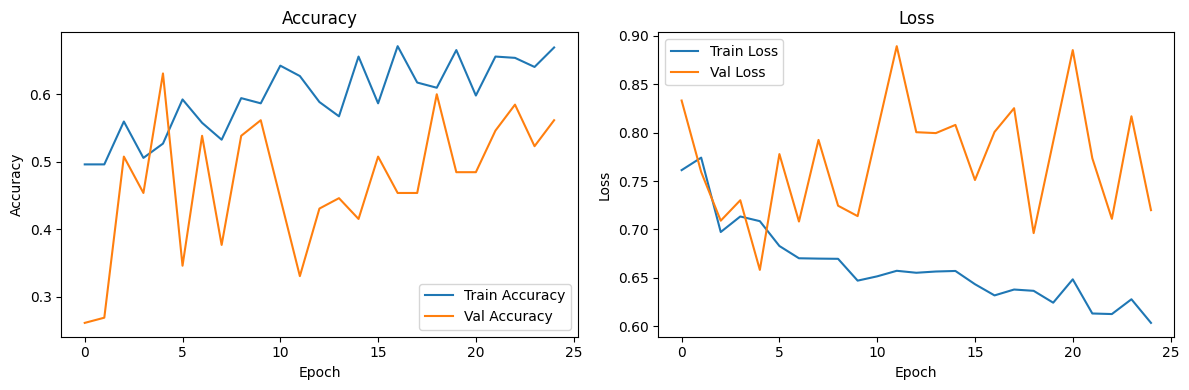

Saved to results/plots/cnn_training_curves.png


In [11]:
os.makedirs('results/plots', exist_ok=True)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('results/plots/cnn_training_curves.png')
plt.show()
print("Saved to results/plots/cnn_training_curves.png")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
                   precision    recall  f1-score   support

Glaucoma_Negative       0.69      0.78      0.74        96
Glaucoma_Positive       0.05      0.03      0.04        34

         accuracy                           0.58       130
        macro avg       0.37      0.41      0.39       130
     weighted avg       0.52      0.58      0.55       130



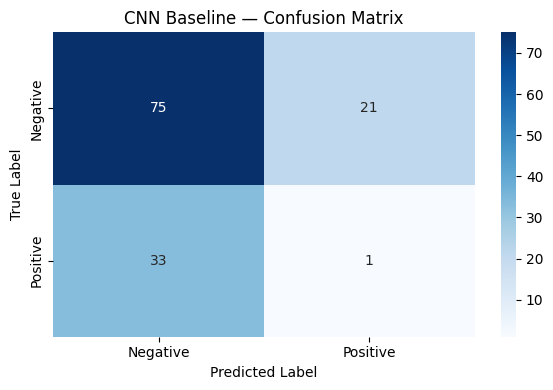

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load best saved model
best_model = tf.keras.models.load_model('models/cnn_binary.h5')

# Get predictions
val_generator.reset()
preds = best_model.predict(val_generator)
pred_classes = (preds > 0.5).astype(int).flatten()
true_classes = val_generator.classes

# Print report
print(classification_report(true_classes, pred_classes, 
      target_names=['Glaucoma_Negative', 'Glaucoma_Positive']))

# Confusion matrix
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('CNN Baseline — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('results/plots/cnn_confusion_matrix.png')
plt.show()